# Sentiment analysis of Spanish Amazon product reviews

## The problem

Online marketplaces accumulate customer opinion faster than anyone can read it. Each review
carries a star rating from 1 to 5, which is easy to aggregate but says only *how* satisfied
the customer was. The text says *why*, and it is the part nobody can process at scale.

Two questions follow from that gap, and this project addresses both:

1. **Can the rating be recovered from the text alone?** If a model can tell a satisfied
   customer from a dissatisfied one by reading the review, the same model can score any
   customer text that carries no rating at all.
2. **Can the corpus be queried in natural language?** Aggregating star averages answers
   *what* is happening. Asking *why are customers returning this product?* requires reading
   the reviews, which is exactly what does not scale.

## The data

[Amazon Reviews Multi](https://www.kaggle.com/datasets/mexwell/amazon-reviews-multi), a
public corpus of Amazon reviews distributed as three files (`train`, `validation`, `test`)
covering six languages. **Only the Spanish reviews are used**, which amounts to 210,000
reviews.

| Column | Content |
|---|---|
| `review_body` | Free text of the review |
| `review_title` | Title written by the customer |
| `stars` | Rating from 1 to 5 (target variable) |
| `product_category` | Product category, e.g. `electronics`, `home`, `apparel` |
| `product_id`, `reviewer_id` | Anonymised identifiers |
| `review_id`, `language` | Review identifier and language code |

The rating doubles as the sentiment label: 1 and 2 stars correspond to a negative experience,
3 to a neutral one, and 4 and 5 to a positive one. The problem can therefore be framed as a
five-level ordinal scale or as a coarser three-way grouping.

## Objectives

**Sentiment classification.** Predict the rating of a review from its text, which is the same
as predicting whether the customer's experience was negative, neutral or positive.

**Retrieval-augmented question answering (RAG).** Build a system that answers questions about
the corpus by retrieving the reviews relevant to the question and grounding the answer in
them, so that a query returns evidence drawn from real customer opinions rather than a
generic response.

## Why it is useful

- Sentiment scoring extends to any customer text with no rating attached: support tickets,
  survey responses, social media mentions.
- A product whose incoming reviews turn negative can be flagged before its star average moves,
  since an average built on hundreds of past ratings reacts slowly.
- Retrieval turns the reasons behind a score into something searchable. *What do customers
  complain about in this category?* becomes a query instead of a week of manual reading.

## Methodology

The modelling follows a progressive path, where each stage is measured against the previous
one so that any added complexity has to justify itself:

1. **Data quality and exploratory analysis.** Establish what the corpus contains, how the
   ratings are distributed, how long the reviews are and what vocabulary they use.
2. **Product-level analysis.** Which products and categories concentrate the best and worst
   opinions, supported by statistical tests rather than by eyeballing averages.
3. **Baseline.** A bag-of-words representation with a linear classifier. It is fast,
   interpretable, and it sets the floor that anything more sophisticated must beat.
4. **Pretrained language model.** A transformer pretrained on Spanish, fine-tuned on this
   corpus, which unlike the baseline can use word order and context.
5. **Formal comparison.** Both models evaluated on the same held-out data, comparing accuracy,
   macro and per-class F1, confusion matrices and inference time. A model that is marginally
   better but far slower is not automatically the right choice.
6. **Embedding visualisation.** Projecting the learned representations to two dimensions to
   see whether the rating levels separate, and where they overlap.
7. **Retrieval system.** A vector database over the reviews, used to answer questions grounded
   in the retrieved text.



# Libraries

In [1]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import emoji

# NLTK 3.10.1 refuses to import any dependency that resolves to a path inside the
# current working directory. The virtual environment lives in ./.venv, so every
# NLTK dependency in site-packages is flagged as untrusted and the import fails.
# Loading them here, before NLTK itself, keeps that check from triggering.
import regex, defusedxml.ElementTree, joblib, tqdm, click

import nltk
from nltk.corpus import stopwords


/home/alejandro/Escritorio/Proyectos portafolio/Amazon Reviews Spanish Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Reproducibility

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)

# Data

The dataset ships as three separate files, `train.csv`, `validation.csv` and `test.csv`,
already partitioned by its authors.

**The three are merged into a single DataFrame.** Exploratory analysis describes a corpus, and
describing a pre-split fragment of it would give a partial and possibly misleading picture:
every quality check would have to be repeated three times, and any statistic would be
conditioned on a partition that has nothing to do with the phenomenon being studied.

**A `split` column is added before merging**, recording which file each row came from. This is
what makes the merge safe rather than destructive: the original partition is preserved inside
the data and can be reproduced exactly at any point, while the corpus can be treated as one
table for analysis. Without that column the merge would be irreversible, and the authors'
partition, which exists so that results are comparable across studies, would be lost.

Each file contains reviews in six languages. Only Spanish is kept.


In [3]:
path = kagglehub.dataset_download("mexwell/amazon-reviews-multi")

print("Path to dataset files:", path)

Path to dataset files: /home/alejandro/.cache/kagglehub/datasets/mexwell/amazon-reviews-multi/versions/1


In [4]:
train = pd.read_csv(f"{path}/train.csv")
test = pd.read_csv(f"{path}/test.csv")
validation = pd.read_csv(f"{path}/validation.csv")

train['split'] = 'train'
test['split'] = 'test'
validation['split'] = 'validation'

In [5]:
df = pd.concat([train, test, validation], ignore_index=True)

df.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
0,0,de_0203609,product_de_0865382,reviewer_de_0267719,1,Armband ist leider nach 1 Jahr kaputt gegangen,Leider nach 1 Jahr kaputt,de,sports,train
1,1,de_0559494,product_de_0678997,reviewer_de_0783625,1,In der Lieferung war nur Ein Akku!,EINS statt ZWEI Akkus!!!,de,home_improvement,train
2,2,de_0238777,product_de_0372235,reviewer_de_0911426,1,"Ein Stern, weil gar keine geht nicht. Es hande...",Achtung Abzocke,de,drugstore,train
3,3,de_0477884,product_de_0719501,reviewer_de_0836478,1,"Dachte, das wären einfach etwas festere Binden...",Zu viel des Guten,de,drugstore,train
4,4,de_0270868,product_de_0022613,reviewer_de_0736276,1,Meine Kinder haben kaum damit gespielt und nac...,Qualität sehr schlecht,de,toy,train


# Data exploration

The corpus is filtered to Spanish and saved before anything else, so the raw subset is always
recoverable. The checks that follow are the basics: size, column types, missing values,
duplicated rows, and how the reviews distribute across the three original files. Nothing is
modified at this stage except the removal of the residual index column.


In [6]:
df_spanish = df[df['language'] == 'es'].copy()

df_spanish.to_csv('amazon_reviews_spanish.csv', index=False)

In [7]:
df_spanish.head()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
400000,400000,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics,train
400001,400001,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics,train
400002,400002,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore,train
400003,400003,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless,train
400004,400004,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes,train


In [8]:
df_spanish.tail()

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
1244995,14995,es_0179515,product_es_0158275,reviewer_es_0273644,5,Me ha encantado la cesta. Ha llegado impecable...,guadalupe,es,home,validation
1244996,14996,es_0894902,product_es_0953259,reviewer_es_0153773,5,Desempeña su función correctamente,calidad precio,es,camera,validation
1244997,14997,es_0760496,product_es_0731995,reviewer_es_0171091,5,Me ha encantado la diadema! Las flores son tal...,Excelente,es,toy,validation
1244998,14998,es_0178380,product_es_0402051,reviewer_es_0686937,5,"A mi me gustan mucho las fundas TPU, ya que so...",Genial,es,wireless,validation
1244999,14999,es_0810087,product_es_0684221,reviewer_es_0613091,5,El artículo ha cumplido con las expectativas q...,Buena calidad,es,apparel,validation


In [9]:
df_spanish.info()

<class 'pandas.DataFrame'>
Index: 210000 entries, 400000 to 1244999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Unnamed: 0        210000 non-null  int64
 1   review_id         210000 non-null  str  
 2   product_id        210000 non-null  str  
 3   reviewer_id       210000 non-null  str  
 4   stars             210000 non-null  int64
 5   review_body       210000 non-null  str  
 6   review_title      210000 non-null  str  
 7   language          210000 non-null  str  
 8   product_category  210000 non-null  str  
 9   split             210000 non-null  str  
dtypes: int64(2), str(8)
memory usage: 17.6 MB


In [10]:
df_spanish.describe()

,Unnamed: 0,stars
count,210000.000000,210000.000000
mean,476785.214286,3.000000
std,118122.098049,1.414217
min,10000.000000,1.000000
25%,442499.750000,2.000000
50%,494999.500000,3.000000
75%,547499.250000,4.000000
max,599999.000000,5.000000


In [11]:
df_spanish['split'].value_counts()

split
train         200000
test            5000
validation      5000
Name: count, dtype: int64

In [12]:
df_spanish.isnull().mean() * 100

Unnamed: 0          0.0
review_id           0.0
product_id          0.0
reviewer_id         0.0
stars               0.0
review_body         0.0
review_title        0.0
language            0.0
product_category    0.0
split               0.0
dtype: float64

In [13]:
df_spanish.duplicated().sum()

np.int64(0)

The checks above modify nothing. The only change made in this section is dropping
`Unnamed: 0`, whose values were just shown to be a residual index carrying no information.


In [14]:
df_spanish = df_spanish.drop(columns=['Unnamed: 0'])

In [15]:
df_spanish.head()

,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category,split
400000,es_0491108,product_es_0296024,reviewer_es_0999081,1,Nada bueno se me fue ka pantalla en menos de 8...,television Nevir,es,electronics,train
400001,es_0869872,product_es_0922286,reviewer_es_0216771,1,"Horrible, nos tuvimos que comprar otro porque ...",Dinero tirado a la basura con esta compra,es,electronics,train
400002,es_0811721,product_es_0474543,reviewer_es_0929213,1,Te obligan a comprar dos unidades y te llega s...,solo llega una unidad cuando te obligan a comp...,es,drugstore,train
400003,es_0359921,product_es_0656090,reviewer_es_0224702,1,"No entro en descalificar al vendedor, solo pue...",PRODUCTO NO RECIBIDO.,es,wireless,train
400004,es_0068940,product_es_0662544,reviewer_es_0224827,1,Llega tarde y co la talla equivocada,Devuelto,es,shoes,train


### Structural inspection: findings

- The Spanish subset contains **210,000 reviews**, distributed as 200,000 / 5,000 / 5,000
  across the three original files.
- **No missing values** in any column, and **no fully duplicated rows**.
- `Unnamed: 0` is a residual index inherited from the source CSVs. Its values range from
  10,000 to 599,999 and overlap across files, so it identifies nothing and is dropped.
- The `language` column is constant (`es`) after filtering. It is kept only for traceability.


## Target distribution

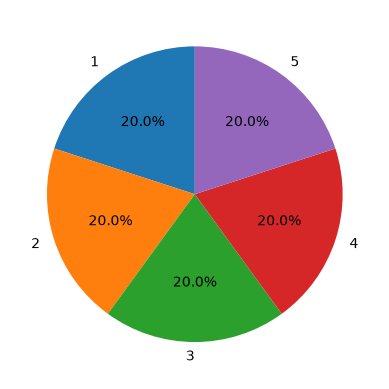

In [16]:
stars = df_spanish['stars'].astype(str)
counts = stars.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

### Target distribution: findings

The five rating levels are **perfectly balanced**: 42,000 reviews per level, mean exactly
3.000 and standard deviation 1.4142.

This balance is **artificial**. The corpus was assembled by design with equal class sizes and
does not reflect the real distribution of Amazon reviews, which is heavily skewed towards 5
stars. Any statement about "the proportion of dissatisfied customers" derived from this
dataset would therefore be invalid: the dataset says nothing about how common each rating is
in reality.

What the balance does allow is a clean comparison of the language used at each rating level,
since no level is over-represented in the vocabulary counts that follow.


# Text analysis

Cleaning is applied to **copies** of the text, never to the original columns.

| Column | Content |
|---|---|
| `review_body`, `review_title` | Original text, never modified |
| `body_clean`, `title_clean` | Normalised text, used for the analysis below |

Keeping the originals serves three purposes: every cleaning step can be verified by reading
the before and after side by side, further variants can be derived without reprocessing the
raw files, and any later use that needs to show a review as the customer wrote it still has
the untouched text available.

Each diagnostic below follows the same procedure: build a mask, measure how many reviews are
affected, read a sample of the matches, and only then decide on a rule. Rules are justified
by measured prevalence, not by convention. A transformation that fixes a problem the corpus
does not have adds risk without adding value.

The measured count then determines the response, and the same criterion is applied throughout:

- **A handful of rows** (one or two in 210,000). The rows are dropped. Removing them has no
  measurable effect on anything, and it avoids adding a permanent rule to the pipeline for a
  case that does not recur.
- **A meaningful number of rows** (hundreds). Dropping them would discard usable data, so the
  artefact has to be transformed rather than removed. This is only worth doing when a reliable
  way of transforming it exists.


## Emojis

Emojis are detected with `emoji.emoji_count`, which works from the official Unicode emoji
table rather than from a hand-written character range, so compound emojis and skin-tone
modifiers are counted correctly. Prevalence is measured separately on the body and the title,
a sample of the matches is read before any decision is taken, and the conversion is verified
afterwards by running the same count again on the cleaned columns.


In [17]:
mask_emoji = df_spanish['review_body'].apply(emoji.emoji_count) > 0
mask_emoji_title = df_spanish['review_title'].apply(emoji.emoji_count) > 0


In [18]:
df_spanish[mask_emoji][['review_body']].sample(10, random_state=seed)

,review_body
599557,Hermética!! Va muy muy bien y es súper bonita 😜
407040,👎🏻 no sé gana nada d peso
447393,"Pierde muy rápido el Bluetooth, se desparejan ..."
443705,Me es difícil escribir una opinión de este pro...
453321,"Son grandes, sobre todo demasiado anchas. Una ..."
448466,Los cuencos muy pequeños para el tamaño de mi ...
554558,"Pedí uno para mí mujer y vino defectuoso, meno..."
569087,"Muy bueno y bonito, pero el primer día la prof..."
472742,Menos de un mes de uso y ya empieza a desinteg...
429166,"Es de plástico y muy fina, es igual que no pon..."


In [19]:
df_spanish[mask_emoji_title][['review_title']].sample(10, random_state=seed)

,review_title
504214,Champú.. 🤷‍♂️
1212217,"Bien para música, llamadas ☹️"
591260,Perfecto 👌🏼
559890,👌🏻
503790,☹️
574774,Correcto 👍🏼
586313,Compra 💯%
555074,Buena..😁
575338,Bonitas 👍🏻
528987,👌🏻


In [20]:
print("Number of reviews with emojis in the body:", mask_emoji.sum())
print("Number of reviews with emojis in the title:", mask_emoji_title.sum())

Number of reviews with emojis in the body: 786
Number of reviews with emojis in the title: 351


In [21]:
print(f"Number of reviews with emojis in the body: {mask_emoji.mean()*100:.2f}%")
print(f"Number of reviews with emojis in the title: {mask_emoji_title.mean()*100:.2f}%")

Number of reviews with emojis in the body: 0.37%
Number of reviews with emojis in the title: 0.17%


Measurement ends here and transformation begins. `demojize` is applied to the full column
rather than to the masked subset, which is simpler and costs the same, and the result is
written to new columns so that the originals stay intact.


In [22]:
df_spanish['body_clean'] = df_spanish['review_body'].apply(
    lambda x: emoji.demojize(x, language='es')
)
df_spanish.loc[mask_emoji, 'body_clean'].sample(10, random_state=seed)

599557    Hermética!! Va muy muy bien y es súper bonita ...
407040    :pulgar_hacia_abajo_tono_de_piel_claro: no sé ...
447393    Pierde muy rápido el Bluetooth, se desparejan ...
443705    Me es difícil escribir una opinión de este pro...
453321    Son grandes, sobre todo demasiado anchas. Una ...
448466    Los cuencos muy pequeños para el tamaño de mi ...
554558    Pedí uno para mí mujer y vino defectuoso, meno...
569087    Muy bueno y bonito, pero el primer día la prof...
472742    Menos de un mes de uso y ya empieza a desinteg...
429166    Es de plástico y muy fina, es igual que no pon...
Name: body_clean, dtype: str

In [23]:
df_spanish['title_clean'] = df_spanish['review_title'].apply(
    lambda x: emoji.demojize(x, language='es')
)
df_spanish.loc[mask_emoji_title, 'title_clean'].sample(10, random_state=seed)

504214                 Champú.. :hombre_encogido_de_hombros:
1212217    Bien para música, llamadas :cara_con_el_ceño_f...
591260     Perfecto :señal_de_aprobación_con_la_mano_tono...
559890     :señal_de_aprobación_con_la_mano_tono_de_piel_...
503790                           :cara_con_el_ceño_fruncido:
574774     Correcto :pulgar_hacia_arriba_tono_de_piel_cla...
586313                                 Compra :cien_puntos:%
555074            Buena..:cara_radiante_con_ojos_sonrientes:
575338      Bonitas :pulgar_hacia_arriba_tono_de_piel_claro:
528987     :señal_de_aprobación_con_la_mano_tono_de_piel_...
Name: title_clean, dtype: str

In [24]:
mask_emoji = df_spanish['body_clean'].apply(emoji.emoji_count) > 0
mask_emoji_title = df_spanish['title_clean'].apply(emoji.emoji_count) > 0


print("Number of reviews with emojis in the body after demojization:", mask_emoji.sum())
print("Number of reviews with emojis in the title after demojization:", mask_emoji_title.sum())

Number of reviews with emojis in the body after demojization: 0
Number of reviews with emojis in the title after demojization: 0


### Emojis: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing emojis | 786 (0.37 %) | 351 (0.17 %) |

**Decision: convert to text with `emoji.demojize(language='es')`; do not delete.**

This is the first artefact that is transformed rather than dropped, and the reason is the
count. URLs and HTML appear in one and two reviews respectively; emojis appear in 786, several
hundred times more. At that volume, dropping the affected rows would mean discarding 786 valid
ratings and 786 valid review texts, which is no longer a cost-free operation.

Transformation is possible because a reliable tool exists for it. The `emoji` library works
from the official Unicode emoji table and produces the Spanish description of each character,
so the conversion is exact and does not depend on hand-written patterns.

Two further reasons support converting over simply deleting the characters:

- An emoji **carries meaning here**. A thumbs-down or an angry face expresses the same opinion
  the rest of the review expresses in words, and stripping it would discard content.
- Several titles consist **exclusively of emojis**. Deleting the characters would leave those
  rows with no text at all; converting them keeps the meaning in the form of Spanish words.


Skin-tone modifiers survive in the resulting aliases (e.g.
`:pulgar_hacia_abajo_tono_de_piel_claro:`). At this prevalence, normalising them would change
nothing measurable and was not implemented.


## URLs

In [25]:
URL_PATTERN = r"(?i)\b(?:https?://|www\.)\S+"


mask_url_body = df_spanish['review_body'].str.contains(URL_PATTERN, regex=True)
mask_url_title = df_spanish['review_title'].str.contains(URL_PATTERN, regex=True)

In [26]:
print(f"Number of reviews with URLs in the body: {mask_url_body.sum()}")
print(f"Number of reviews with URLs in the title: {mask_url_title.sum()}")

Number of reviews with URLs in the body: 1
Number of reviews with URLs in the title: 0


In [27]:
df_spanish=df_spanish[~ mask_url_body & ~mask_url_title].copy()

In [28]:
df_spanish.shape

(209999, 11)

### URLs: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing URLs | 1 | 0 |

**Decision: drop the affected row.**

One occurrence in 210,000 reviews is a negligible quantity: removing it cannot affect any
result. Writing a substitution rule for a single case would add permanent code to the pipeline
in exchange for nothing, so the row is dropped instead.


## Email addresses

In [29]:
EMAIL_PATTERN = r"(?i)\b[\w-]+@[\w-]+\.(?:com|es|net|org|info|io|store|online)\b"

mask_email_body = df_spanish['review_body'].str.contains(EMAIL_PATTERN, regex=True)
mask_email_title = df_spanish['review_title'].str.contains(EMAIL_PATTERN, regex=True)

In [30]:
print(f"Number of reviews with emails in the body: {mask_email_body.sum()}")
print(f"Number of reviews with emails in the title: {mask_email_title.sum()}")

Number of reviews with emails in the body: 0
Number of reviews with emails in the title: 0


### Email addresses: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| Reviews containing email addresses | 0 | 0 |

**Decision: no treatment required.** The phenomenon does not occur in this corpus. This also
means the dataset carries no personal contact details in its free text.


## HTML

In [31]:
HTML_TAG_PATTERN = r"<[^>]+>"
HTML_ENTITY_PATTERN = r"&[a-zA-Z]+;|&#\d+;"

mask_html_tag_body = df_spanish['review_body'].str.contains(HTML_TAG_PATTERN, regex=True)
mask_html_tag_title = df_spanish['review_title'].str.contains(HTML_TAG_PATTERN, regex=True)

mask_html_ent_body = df_spanish['review_body'].str.contains(HTML_ENTITY_PATTERN, regex=True)
mask_html_ent_title = df_spanish['review_title'].str.contains(HTML_ENTITY_PATTERN, regex=True)

print(f"Number of reviews with HTML tags in the body: {mask_html_tag_body.sum()}")
print(f"Number of reviews with HTML tags in the title: {mask_html_tag_title.sum()}")
print(f"Number of reviews with HTML entities in the body: {mask_html_ent_body.sum()}")
print(f"Number of reviews with HTML entities in the title: {mask_html_ent_title.sum()}")


Number of reviews with HTML tags in the body: 2
Number of reviews with HTML tags in the title: 0
Number of reviews with HTML entities in the body: 0
Number of reviews with HTML entities in the title: 0


In [ ]:
df_spanish = df_spanish[~mask_html_tag_body & ~mask_html_tag_title & ~mask_html_ent_body & ~mask_html_ent_title].copy()


In [33]:
df_spanish.shape

(209997, 11)

### HTML: findings and decision

| | `review_body` | `review_title` |
|---|---|---|
| HTML tags | 2 | 0 |
| HTML entities | 0 | 0 |

**Decision: drop the affected rows.**

HTML markup such as `<br />` and `&amp;` is common in raw review corpora scraped from the
web, so its near-absence here is worth stating explicitly: this dataset was already sanitised
before publication, and no HTML-stripping stage is needed.

**Decision: drop the affected rows.** Two occurrences in 210,000 reviews is, as with the URL,
a negligible quantity, and the same criterion applies: dropping costs nothing and keeps the
pipeline free of rules written for cases that occur twice.

After this step the dataset contains **209,997 reviews**, three fewer than the original
210,000: one removed for the URL and two for HTML.


## Whitespace

In [ ]:
df_spanish['body_clean'] = (
    df_spanish['body_clean'].str.replace(r"\s+", " ", regex=True).str.strip()
)
df_spanish['title_clean'] = (
    df_spanish['title_clean'].str.replace(r"\s+", " ", regex=True).str.strip()
)



### Whitespace: findings and decision

No anomalous whitespace (repeated spaces, leading or trailing spaces) was found in the
original columns.

**Decision: apply the normalisation anyway.** Collapsing `\s+` to a single space and trimming
the ends costs nothing and guards against spacing artefacts introduced by the preceding
transformations. The rule is placed last in the cleaning sequence so that it also normalises
the output of every earlier step.

In Python 3, `\s` on Unicode strings already covers non-breaking and typographic spaces as
well as tabs and line breaks, so this single rule also handles line breaks. The zero-width
space (`\u200b`) is the one exception and would need a separate check.


## Post-cleaning check

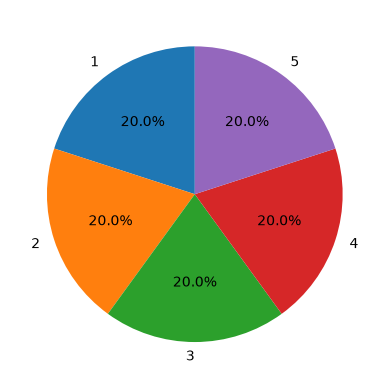

In [35]:
stars = df_spanish['stars'].astype(str)
counts = stars.value_counts().sort_index()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.show()

In [ ]:
stars.value_counts().sort_index()

stars
4    42000
5    42000
1    41999
2    41999
3    41999
Name: count, dtype: int64

In [37]:
df_spanish['body_clean'].sample(10, random_state=seed)

453693                              No de muy buena calidad
599538    Todo perfecto y al instante. Gran servicio de ...
598042    Hilo dental perfecto para los que, después de ...
559007    era un regalo para mi sobrino que cumplia 3 añ...
441019    Con el móvil negro queda muy feo y se raya muy...
424779    Tratando el cable bien a los 4 meses me ha dej...
543814    Magnífica batidora. La única pega que he encon...
591769    El paquete llega muy bien envuelto con su plás...
571433    Excelente. Móvil nuevo y muy bien empacado. Re...
556098    La encontré de oferta y la aproveché. Está bie...
Name: body_clean, dtype: str

In [38]:
df_spanish['title_clean'].sample(10, random_state=seed)

453693                     Un buen regalo
599538                     Fácil y rápido
598042    Muy útil y más que recomendable
559007                           perfecto
441019      No queda tan bien como parece
424779                            Eduardo
543814                     Buena batidora
591769                     Muy satisfecho
571433              Llego a tiempo récord
556098                 Ideal para empezar
Name: title_clean, dtype: str

### After cleaning: verification

The class distribution is **practically unchanged**: 42,000 reviews in levels 4 and 5, and
41,999 in levels 1, 2 and 3. The three rows removed during cleaning represent 0.0014 % of the
corpus, and the balance that made the rating levels directly comparable is preserved. The pie
chart is visually identical to the one produced before cleaning.

Reading a sample of `body_clean` and `title_clean` confirms the text remains natural Spanish.
The only visible difference from the originals is where an emoji has become its written
description; nothing else about the wording, punctuation or capitalisation has been altered.


In [39]:
df_spanish.to_csv('amazon_reviews_spanish_cleaned.csv', index=False)

# Text length and word frequency

Length is measured in characters on the cleaned columns, since those are the ones the rest of
the analysis uses. Each field is first summarised numerically and then shown twice: a boxplot,
which makes the spread and the outliers visible, and a histogram, which shows the shape of the
distribution. Body and title are treated separately because they are different kinds of text.


In [40]:
text_lengths = df_spanish['body_clean'].str.len()

In [41]:
text_lengths.describe()

count    209997.000000
mean        151.395925
std         132.117227
min          16.000000
25%          68.000000
50%         120.000000
75%         186.000000
max        3086.000000
Name: body_clean, dtype: float64

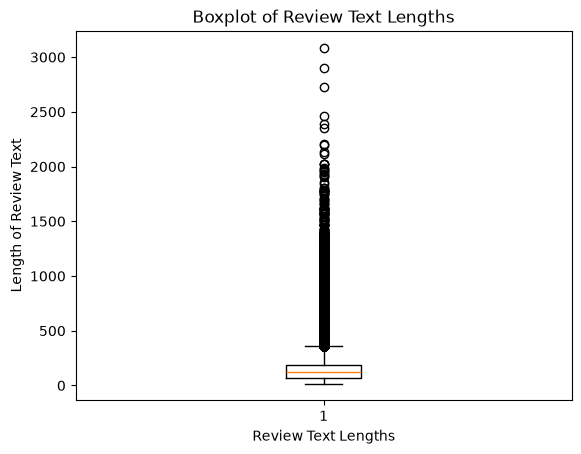

In [42]:
plt.boxplot(text_lengths)
plt.title('Boxplot of Review Text Lengths')
plt.ylabel('Length of Review Text')
plt.xlabel('Review Text Lengths')
plt.show()

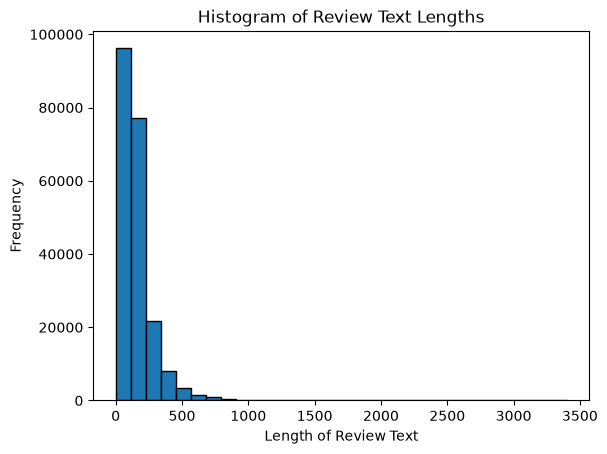

In [43]:
plt.hist(text_lengths, bins=30, edgecolor='black', range=(0, 3400))
plt.title('Histogram of Review Text Lengths')
plt.xlabel('Length of Review Text')
plt.ylabel('Frequency')
plt.show()

In [44]:
title_length = df_spanish['title_clean'].str.len()

In [45]:
title_length.describe()

count    209997.000000
mean         19.217251
std          13.471689
min           1.000000
25%          10.000000
50%          16.000000
75%          25.000000
max         171.000000
Name: title_clean, dtype: float64

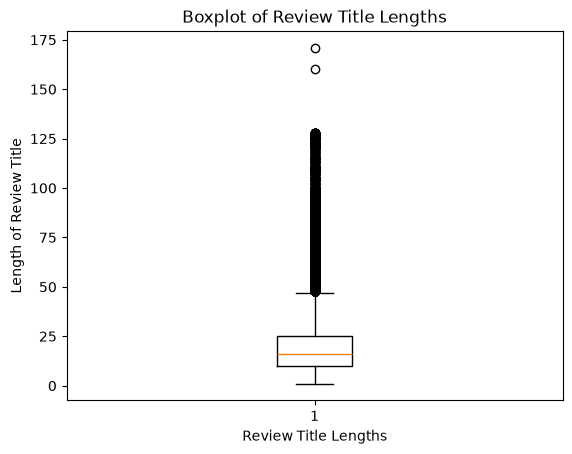

In [46]:
plt.boxplot(title_length)
plt.title('Boxplot of Review Title Lengths')
plt.ylabel('Length of Review Title')
plt.xlabel('Review Title Lengths')
plt.show()

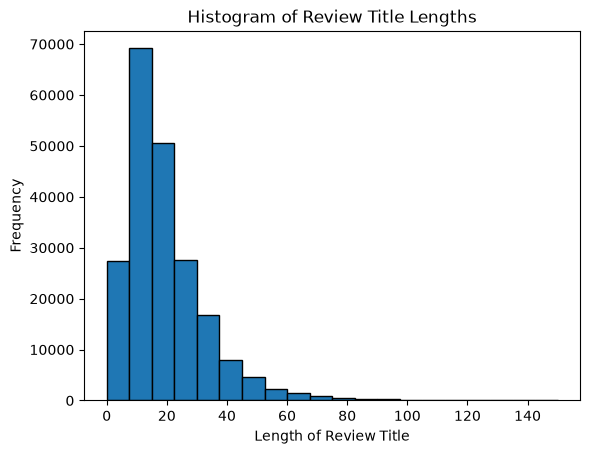

In [47]:
plt.hist(title_length, bins=20, edgecolor='black', range=(0, 150))
plt.title('Histogram of Review Title Lengths')
plt.xlabel('Length of Review Title')
plt.ylabel('Frequency')
plt.show()

### Text length: findings

| | `body_clean` | `title_clean` |
|---|---|---|
| Mean | 151.4 | 19.2 |
| Median | 120 | 16 |
| 25th percentile | 68 | 10 |
| 75th percentile | 186 | 25 |
| 95th percentile | 390 | n/a |
| 99th percentile | 665 | n/a |
| Maximum | 3,086 | 171 |
| Minimum | 16 | 1 |

**These are short texts.** A median of 120 characters is roughly twenty words, about two
sentences. A quarter of all reviews fit in 68 characters, which is a single short sentence,
and three quarters fit in 186. Titles are shorter still: a median of 16 characters, two or
three words, closer to a label than to a sentence: *Excelente*, *Devuelto*, *Buena calidad*.

Both distributions are strongly right-skewed: a dense mass of very short reviews and a thin
tail reaching 3,086 characters. The boxplots mark a large number of high outliers, but reading
them confirms they are legitimate detailed reviews, not corrupted records. Only 1 % of the
corpus exceeds 665 characters.

The practical reading is that customers here write brief, direct verdicts rather than
reasoned essays. There is little room in 120 characters for qualification or nuance, which
suggests the opinion is usually stated plainly and in few words. It also means there is not
much material for any analysis that depends on long-form structure; whatever signal exists is
concentrated in the choice of a handful of words.


In [48]:
nltk.download('stopwords')

# Negations and adversatives are on the standard Spanish stopword list, but they carry
# the polarity of the sentence, so they are kept.
NEGATIONS = {'no', 'ni', 'nunca', 'nada', 'sin', 'pero', 'tampoco', 'jamás'}
STOPWORDS_ES = set(stopwords.words('spanish')) - NEGATIONS

TOKEN_PATTERN = r"[a-záéíóúüñ]{2,}"


def top_words(series, n=10):
    words = series.str.lower().str.findall(TOKEN_PATTERN).explode()
    return words[~words.isin(STOPWORDS_ES)].value_counts().head(n)


print(top_words(df_spanish['body_clean']))
print(top_words(df_spanish['title_clean']))


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/alejandro/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


body_clean
no          163127
pero         68149
bien         54174
calidad      33528
si           26432
producto     25869
precio       24155
buena        20402
nada         16990
sin          16966
Name: count, dtype: int64
title_clean
no          31981
calidad     16419
bien        12503
buena       10481
precio       9043
buen         7993
pero         7826
producto     7777
mal          4620
perfecto     4442
Name: count, dtype: int64


### Most frequent words: findings

Computed on `body_clean` and `title_clean` after lowercasing, tokenising and removing Spanish
stopwords.

**The stopword list was filtered before use.** The standard NLTK Spanish list includes `no`,
`ni`, `nunca`, `nada`, `sin` and `pero`. In the unfiltered count, `pero` appears 68,149 times,
`nada` 16,990 and `sin` 16,966. These are not filler words here: `nada` reverses the meaning
of what follows, `sin` marks something the product lacks, and `pero` introduces the clause
that usually carries the actual verdict. Removing them would erase more than 100,000
occurrences of the most informative tokens in the corpus, so they are explicitly excluded
from the stopword set.

Evaluative terms such as *bien*, *calidad*, *precio*, *buena* and *perfecto* rank high, with
frequencies in the tens of thousands. Together with the two recurring themes that emerge,
quality and price, this indicates the vocabulary is concentrated and repetitive rather than
diffuse.

One limitation of this analysis is worth recording: counting single words cannot separate
"funciona perfectamente" from "no funciona". The word `funciona` is identical in both, and
only the pair of words distinguishes praise from complaint. Frequency counts therefore
describe what customers talk about, not what they conclude.
